# Driving School Installs Prediction (BiLSTM)

In [1]:
import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## Hyperparameters

In [2]:
TRAIN_RATIO = 0.8
WINDOW_SIZE = 30
BATCH_SIZE = 32

HIDDEN_DIM = 64
NUM_LAYERS = 2
DROPOUT = 0.2
LEARNING_RATE = 0.001
EPOCHS = 30

DATA_CSV_FILE = "../../../data/ds_data_clean.csv"

## Loading Data

In [3]:
import pandas as pd

df = pd.read_csv(DATA_CSV_FILE)
df["Date"] = pd.to_datetime(df["Date"])
df["Is Weekend"] = (df["Date"].dt.dayofweek >= 5).astype(int)
df.head()

,Date,Package Name,Daily Device Installs,Daily Device Uninstalls,Daily Device Upgrades,Total User Installs,Daily User Installs,Daily User Uninstalls,Active Device Installs,Install events,Update events,Uninstall events,Daily Average Rating,Total Average Rating,Daily Crashes,Daily ANRs,Is Weekend
0,2019-09-02,com.SGS.DrivingSchoolGames.RealCarParkingSimul...,2,0,0,0,2,1,1,2,0,1,0.0,0.0,0,0,0
1,2019-09-03,com.SGS.DrivingSchoolGames.RealCarParkingSimul...,1,0,0,0,1,0,3,2,1,0,0.0,0.0,0,0,0
2,2019-09-04,com.SGS.DrivingSchoolGames.RealCarParkingSimul...,2,0,0,0,2,0,6,2,0,0,0.0,0.0,0,0,0
3,2019-09-05,com.SGS.DrivingSchoolGames.RealCarParkingSimul...,3,0,0,0,3,2,6,3,0,2,0.0,0.0,0,0,0
4,2019-09-06,com.SGS.DrivingSchoolGames.RealCarParkingSimul...,6,0,0,0,6,2,9,6,0,2,0.0,0.0,0,0,0


## Preprocessing and Temporal Split

In [4]:
from preprocessing_utils import preprocess_time_series

features = [
    "Daily Device Installs",
    "Daily Device Uninstalls",
    "Daily User Installs",
    "Daily User Uninstalls",
    "Active Device Installs",
    "Daily Average Rating",
    "Daily Crashes",
    "Daily ANRs",
    "Is Weekend",
]
target_col = "Daily User Installs"

prep = preprocess_time_series(
    df=df,
    features=features,
    target_col=target_col,
    window_size=WINDOW_SIZE,
    train_ratio=TRAIN_RATIO,
    batch_size=BATCH_SIZE,
)

train_size = prep["train_size"]
train_df = prep["train_df"]
test_df = prep["test_df"]
scaler_x = prep["scaler_x"]
scaler_y = prep["scaler_y"]
train_x_scaled = prep["train_x_scaled"]
train_y_scaled = prep["train_y_scaled"]
test_x_scaled = prep["test_x_scaled"]
test_y_scaled = prep["test_y_scaled"]
X_train = prep["X_train"]
y_train = prep["y_train"]
X_test = prep["X_test"]
y_test = prep["y_test"]
train_loader = prep["train_loader"]

window_size = WINDOW_SIZE

## BiLSTM Architecture

In [5]:
import torch.nn as nn

class BiLSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim, dropout=0.2):
        super(BiLSTMModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.bilstm = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=True,
        )
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers * 2, x.size(0), self.hidden_dim).to(x.device)
        out, _ = self.bilstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out


bilstm_model = BiLSTMModel(
    input_dim=len(features),
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    output_dim=1,
    dropout=DROPOUT,
)
bilstm_optimizer = torch.optim.Adam(bilstm_model.parameters(), lr=LEARNING_RATE)
bilstm_criterion = nn.MSELoss()

## Training the BiLSTM

In [6]:
bilstm_model.train()
for epoch in range(EPOCHS):
    bilstm_epoch_loss = 0
    for batch_x, batch_y in train_loader:
        bilstm_optimizer.zero_grad()
        bilstm_outputs = bilstm_model(batch_x)
        bilstm_loss = bilstm_criterion(bilstm_outputs, batch_y)
        bilstm_loss.backward()
        bilstm_optimizer.step()
        bilstm_epoch_loss += bilstm_loss.item()

    if (epoch + 1) % 5 == 0:
        print(
            f"BiLSTM Epoch {epoch+1}/{EPOCHS}, Loss: {bilstm_epoch_loss/len(train_loader):.6f}"
        )

BiLSTM Epoch 5/30, Loss: 0.179905
BiLSTM Epoch 10/30, Loss: 0.069904
BiLSTM Epoch 15/30, Loss: 0.078154
BiLSTM Epoch 20/30, Loss: 0.039760
BiLSTM Epoch 25/30, Loss: 0.063613
BiLSTM Epoch 30/30, Loss: 0.052538


## BiLSTM Evaluation

------------------------------
BILSTM EVALUATION RESULTS
------------------------------
RMSE: 6373.87 installs
MAE:  4014.98 installs
------------------------------


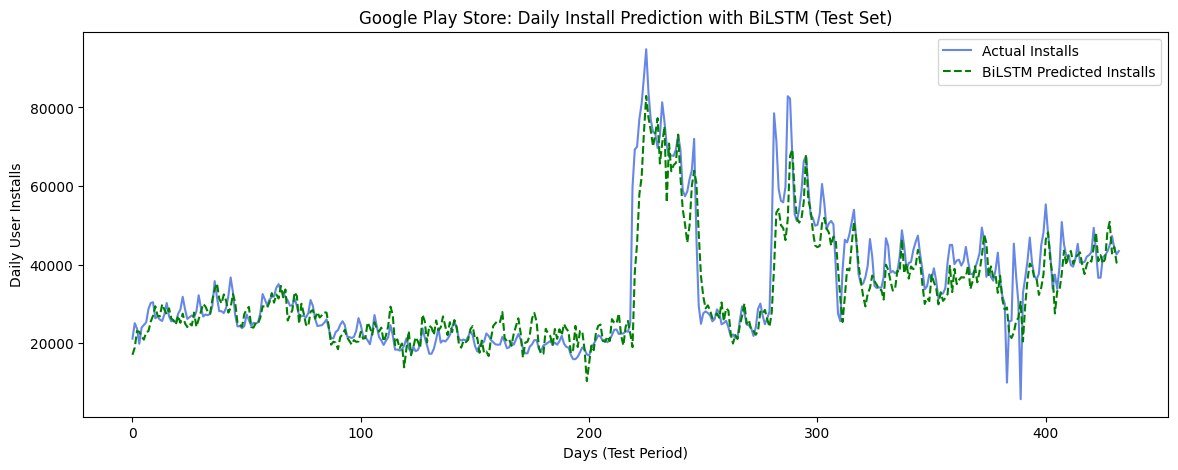

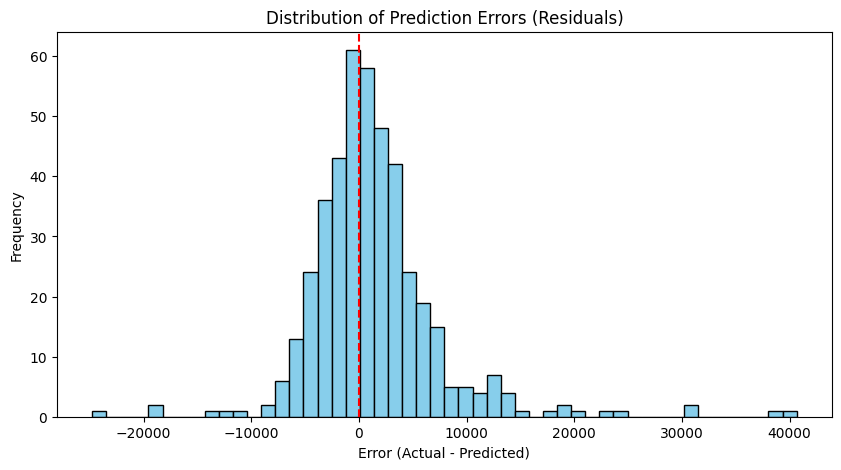

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

bilstm_model.eval()
with torch.no_grad():
    bilstm_pred_scaled = bilstm_model(X_test)
    bilstm_pred = scaler_y.inverse_transform(bilstm_pred_scaled.numpy())
    bilstm_actual = scaler_y.inverse_transform(y_test.numpy())

bilstm_rmse = np.sqrt(mean_squared_error(bilstm_actual, bilstm_pred))
bilstm_mae = mean_absolute_error(bilstm_actual, bilstm_pred)

print("-" * 30)
print("BILSTM EVALUATION RESULTS")
print("-" * 30)
print(f"RMSE: {bilstm_rmse:.2f} installs")
print(f"MAE:  {bilstm_mae:.2f} installs")
print("-" * 30)

plt.figure(figsize=(14, 5))
plt.plot(bilstm_actual, label="Actual Installs", color="royalblue", alpha=0.8)
plt.plot(bilstm_pred, label="BiLSTM Predicted Installs", color="green", linestyle="--")
plt.title("Google Play Store: Daily Install Prediction with BiLSTM (Test Set)")
plt.xlabel("Days (Test Period)")
plt.ylabel("Daily User Installs")
plt.legend()
plt.show()

# Error Distribution Plot
errors = bilstm_actual - bilstm_pred
plt.figure(figsize=(10, 5))
plt.hist(errors, bins=50, color="skyblue", edgecolor="black")
plt.axvline(0, color="red", linestyle="--")
plt.title("Distribution of Prediction Errors (Residuals)")
plt.xlabel("Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.show()

## Save BiLSTM Model

In [8]:
bilstm_checkpoint = {
    "model_state_dict": bilstm_model.state_dict(),
    "optimizer_state_dict": bilstm_optimizer.state_dict(),
    "features": features,
    "target_col": target_col,
    "window_size": window_size,
    "seed": SEED,
    "model_type": "BiLSTM",
}
torch.save(bilstm_checkpoint, "bilstm_model_checkpoint.pth")

print("Model saved to bilstm_model_checkpoint.pth")

Model saved to bilstm_model_checkpoint.pth
